In [1]:
# Importing Lib
import pandas as pd
import numpy as np

In [2]:
dataset = pd.read_csv("twitter.csv")

In [3]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies


In [4]:
dataset.isnull().sum() 

Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

In [5]:
dataset.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [6]:
dataset.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


In [7]:
dataset["labels"] = dataset["class"].map({0: "Hate Speech",
                                         1: "Offensive Language",
                                         2: "No hate or offensive language"})

In [8]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,labels
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,No hate or offensive language
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an...",No hate or offensive language
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies,Offensive Language


In [9]:
data = dataset[["tweet", "labels"]]

In [10]:
data

,tweet,labels
0,!!! RT @mayasolovely: As a woman you shouldn't...,No hate or offensive language
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...
24778,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,"you've gone and broke the wrong heart baby, an...",No hate or offensive language
24780,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,youu got wild bitches tellin you lies,Offensive Language


In [11]:
import re
import nltk
import string

In [12]:
# Importing stop words
from nltk.corpus import stopwords
stopwords = set(stopwords.words("english"))

In [13]:
# Import stemming
stemmer = nltk.SnowballStemmer("english")

In [14]:
# Data cleaning
def clean_data(text):
    text = str(text).lower()
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    # Stop words removal
    text = [word for word in text.split(' ') if word not in stopwords]
    text = " ".join(text)
    # Stemming the text
    text = [stemmer.stem(word) for word in text.split(' ')]
    text = " ".join(text)
    return text

In [15]:
data

,tweet,labels
0,!!! RT @mayasolovely: As a woman you shouldn't...,No hate or offensive language
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...
24778,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,"you've gone and broke the wrong heart baby, an...",No hate or offensive language
24780,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,youu got wild bitches tellin you lies,Offensive Language


In [16]:
X = np.array(data["tweet"])
y = np.array(data["labels"])

In [17]:
X

array(["!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...",
       '!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!',
       '!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit',
       ...,
       'young buck wanna eat!!.. dat nigguh like I aint fuckin dis up again',
       'youu got wild bitches tellin you lies',
       '~~Ruffled | Ntac Eileen Dahlia - Beautiful color combination of pink, orange, yellow &amp; white. A Coll http://t.co/H0dYEBvnZB'],
      shape=(24783,), dtype=object)

In [18]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [19]:
cv = CountVectorizer()
X = cv.fit_transform(X)

In [20]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 324058 stored elements and shape (24783, 35852)>

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [22]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 217297 stored elements and shape (16604, 35852)>

In [23]:
# Building out ML Model
from sklearn.tree import DecisionTreeClassifier

In [24]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
y_pred = dt.predict(X_test)

In [26]:
# Confusion matrix and accuracy
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 114,   42,  309],
       [  35, 1195,  149],
       [ 197,  161, 5977]])

In [27]:
import seaborn as sns
import matplotlib.pyplot as ply
%matplotlib inline

<Axes: >

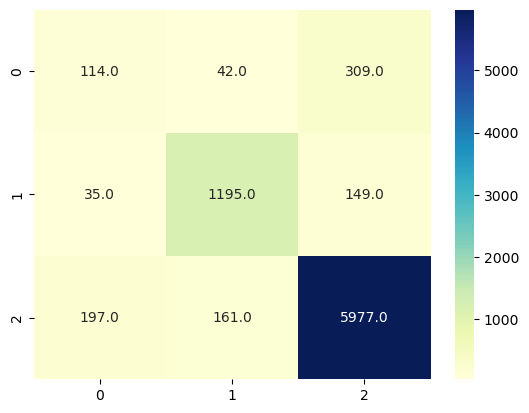

In [28]:
sns.heatmap(cm, annot = True, fmt=".1f", cmap="YlGnBu")

In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8908179484044504

In [30]:
sample = "Let's unite and kill all the people who are protesting against the government"


In [31]:
sample

"Let's unite and kill all the people who are protesting against the government"

In [32]:
data1 = cv.transform([sample]).toarray()

In [33]:
data1

array([[0, 0, 0, ..., 0, 0, 0]], shape=(1, 35852))

In [34]:
dt.predict(data1)

array(['Hate Speech'], dtype=object)

[INIT] LightGBM not installed. Defaulting to baseline tree ensembles.

Executing Production-Grade Analytical Engine...

[FEATURE ENGINEERING] Extracting deep text profiles...
Engine Features Extracted successfully:
               count       mean        std   min       25%        50%  \
char_length  24783.0  85.436065  41.548238  5.00  52.00000  81.000000   
word_count   24783.0  14.117016   6.825525  1.00   9.00000  13.000000   
caps_ratio   24783.0   0.058840   0.052956  0.00   0.02381   0.045455   
punct_count  24783.0   3.029617   3.059140  0.00   1.00000   2.000000   
mention_cnt  24783.0   0.778235   0.875771  0.00   0.00000   1.000000   
hashtag_cnt  24783.0   0.778961   2.006578  0.00   0.00000   0.000000   
readability  24783.0  15.088986   8.466829 -8.94  10.00750  14.414286   

                    75%         max  
char_length  119.000000  754.000000  
word_count    19.000000   52.000000  
caps_ratio     0.078947    0.647059  
punct_count    4.000000   78.000000  
mention_cn

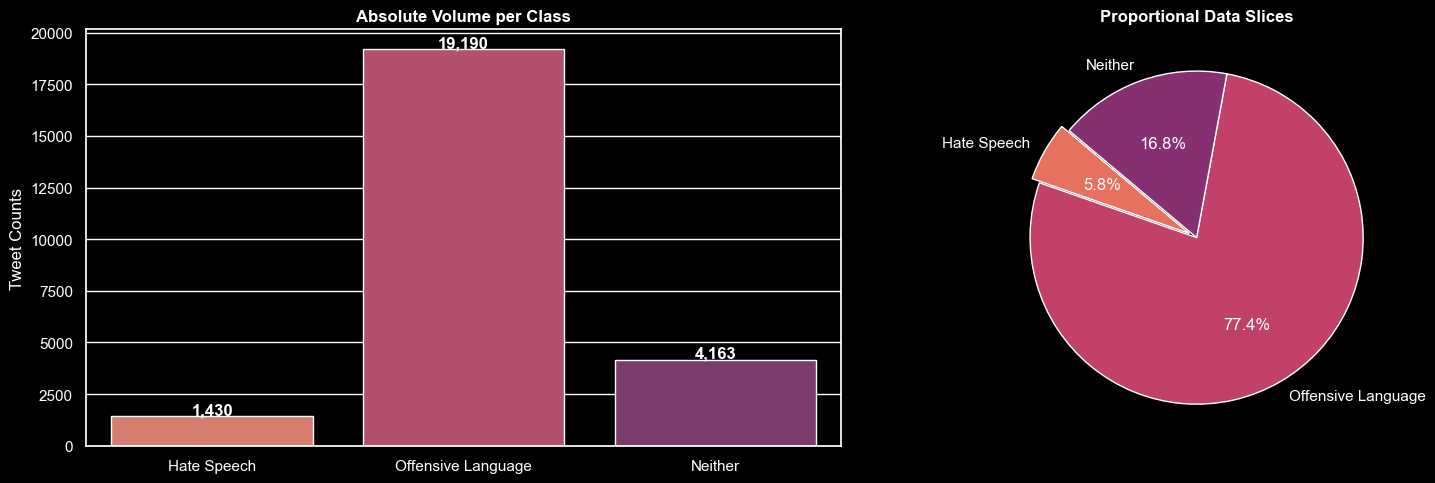

Structural Class Imbalance Ratio: 13.42
Shannon Uncertainty Entropy: 0.955 bits
System Gini Index Impurity: 0.369

----------------------------------------
[ANALYSIS 2] MULTI-VARIATE LINGUISTIC PROFILES
----------------------------------------


C:\Users\soham\AppData\Local\Temp\ipykernel_36488\1445107157.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(display_names)
C:\Users\soham\AppData\Local\Temp\ipykernel_36488\1445107157.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dataset, x='class', y='caps_ratio', palette="magma", ax=axes[1,0])
C:\Users\soham\AppData\Local\Temp\ipykernel_36488\1445107157.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(display_names)


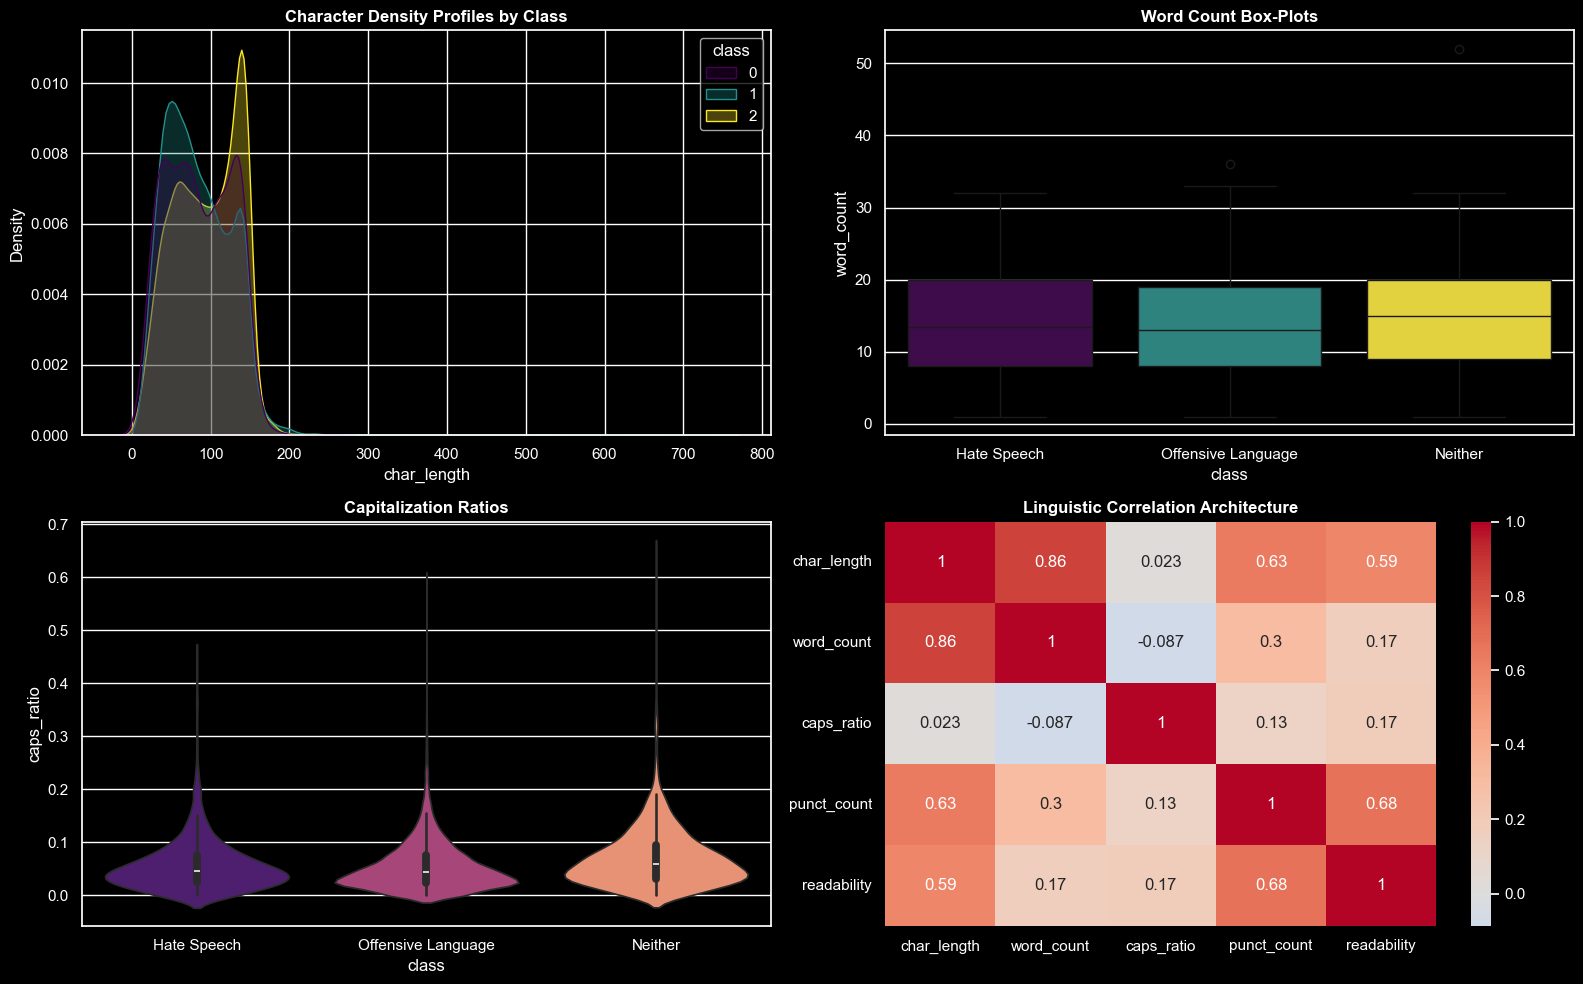


[INTERACTIVE DASHBOARD] Generating Interface Panels...



----------------------------------------
[ANALYSIS 3] VARIANCE INFERENCE & HYPOTHESIS TESTING
----------------------------------------
Parametric ANOVA F-Stat: 34.695 (p = 8.975e-16)
Non-Parametric Kruskal H-Stat: 78.332 (p = 9.782e-18)
Levene Homoscedasticity Evaluation W-Stat: 7.329 (p = 6.577e-04)

[ANALYSIS 4] EMPIRICAL BOOTSTRAP RESAMPLING (N=1000)...
95% Bootstrap Confidence Interval for Mean Word Count: [14.038, 14.204]

----------------------------------------
[ANALYSIS 5 & 6] LEXICON FREQUENCY PROFILE
----------------------------------------
Type-Token Ratio (Lexical Diversity): 0.1036
Hapax Legomena Metric Count: 23054 (Words emerging exactly once)
Top 10 Categorical Class-Associated Token Chains via Chi-Squared Extraction:
  1. Token: [bitch] -> Score: 1963.07
  2. Token: [trash] -> Score: 1627.54
  3. Token: [yankees] -> Score: 1347.32
  4. Token: [faggot] -> Score: 1201.82
  5. Token: [charlie] -> Score: 1129.06
  6. Token: [bird] -> Score: 1074.51
  7. Token: [yellow] ->

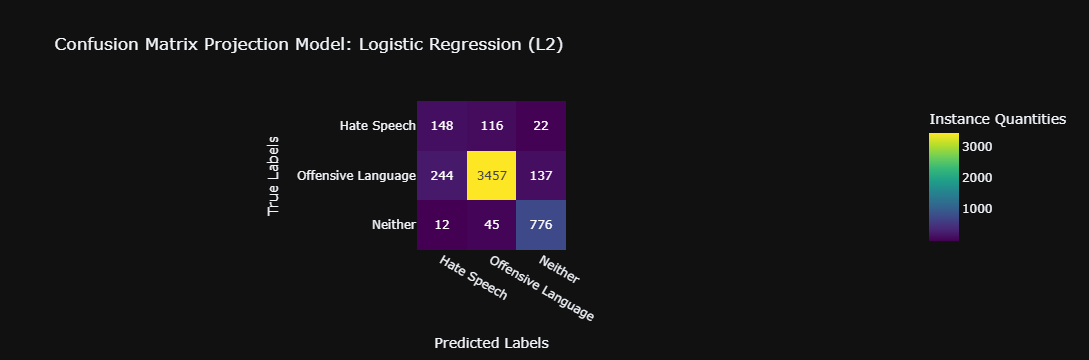


----------------------------------------
[ANALYSIS 11 & 12] SYSTEM VALIDATION AND GENERALIZATION PROPERTIES
----------------------------------------
Optimal Multiclass One-vs-Rest Generalized ROC-AUC Area Metric: 0.9156
[CROSS-VALIDATION] Computing generalized operational capabilities...
Stratified Cross-Validated Bounds Configuration Analysis:
  Mean Distribution Accuracy: 0.8801
  Empirical Standard Error Deviation Bounds: (+/-) 0.0053

Consolidated Architecture and Analytics Run Finished.


In [35]:
# ==============================================================================
# ADVANCED TEXT ANALYTICS, LINGUISTIC FEATURE ENGINEERING, AND PREDICTIVE PIPELINE
# ==============================================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output

# Statistics & Analytics
from scipy.stats import entropy, skew, kurtosis, f_oneway, kruskal, shapiro, normaltest, pointbiserialr, levene
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from sklearn.utils import resample
from sklearn.feature_selection import chi2

# Model Training & Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Attempt to include LightGBM for state-of-the-art tree boosting
try:
    import lightgbm as lgb
    HAS_LGBM = True
    print("[INIT] LightGBM detected. Enabling gradient boosted pipelines.")
except ImportError:
    HAS_LGBM = False
    print("[INIT] LightGBM not installed. Defaulting to baseline tree ensembles.")

# --- Dark Mode Plot Style Configuration ---
sns.set_theme(style="darkgrid", context="notebook")
plt.style.use("dark_background")

print("\nExecuting Production-Grade Analytical Engine...\n" + "="*80)

# --- Configuration & Validation Meta ---
display_names = ['Hate Speech', 'Offensive Language', 'Neither']

# --------------------------------------------------------------------------
# EXTENSION: ADVANCED LINGUISTIC FEATURE ENGINEERING
# --------------------------------------------------------------------------
print("\n[FEATURE ENGINEERING] Extracting deep text profiles...")

def compute_ari(chars, words):
    """Computes an automated readability index approximation for micro-texts."""
    if words == 0: return 0
    # Custom baseline coefficients modified for social media syntax weights
    return 4.71 * (chars / words) + 0.5 * (words / 1.0) - 21.43

dataset['char_length']  = dataset['tweet'].astype(str).apply(len)
dataset['word_count']   = dataset['tweet'].astype(str).apply(lambda r: len(r.split()))
dataset['caps_ratio']   = dataset['tweet'].astype(str).apply(lambda r: sum(1 for c in r if c.isupper()) / (len(r) + 1))
dataset['punct_count']  = dataset['tweet'].astype(str).apply(lambda r: len(re.findall(r'[!.,?@#$]', r)))
dataset['mention_cnt']  = dataset['tweet'].astype(str).apply(lambda r: len(re.findall(r'@\w+', r)))
dataset['hashtag_cnt']  = dataset['tweet'].astype(str).apply(lambda r: len(re.findall(r'#\w+', r)))
dataset['readability']  = dataset.apply(lambda row: compute_ari(row['char_length'], row['word_count']), axis=1)

print("Engine Features Extracted successfully:")
print(dataset[['char_length', 'word_count', 'caps_ratio', 'punct_count', 'mention_cnt', 'hashtag_cnt', 'readability']].describe().T)

# --------------------------------------------------------------------------
# ANALYSIS 1: GLOBAL CLASS DISTRIBUTION & METRICS
# --------------------------------------------------------------------------
print("\n" + "-"*40 + "\n[ANALYSIS 1] GLOBAL CLASS DISTRIBUTION\n" + "-"*40)

raw_counts = dataset['class'].value_counts().sort_index()
proportions = dataset['class'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=display_names, y=raw_counts.values, ax=ax[0], palette="flare", hue=display_names, legend=False)
ax[0].set_title("Absolute Volume per Class", fontweight='bold')
ax[0].set_ylabel("Tweet Counts")
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2., p.get_height()),
                   ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

ax[1].pie(proportions.values, labels=display_names, autopct='%1.1f%%', startangle=140,
          colors=sns.color_palette("flare", 3), explode=(0.05, 0, 0))
ax[1].set_title("Proportional Data Slices", fontweight='bold')
plt.tight_layout()
plt.show()

# Structural Entropies
class_entropy = entropy(proportions, base=2)
gini_index = 1 - np.sum(proportions**2)
print(f"Structural Class Imbalance Ratio: {raw_counts.max() / raw_counts.min():.2f}")
print(f"Shannon Uncertainty Entropy: {class_entropy:.3f} bits")
print(f"System Gini Index Impurity: {gini_index:.3f}")

# --------------------------------------------------------------------------
# ANALYSIS 2: MULTI-VARIATE DISTRIBUTIONS & PLOTS
# --------------------------------------------------------------------------
print("\n" + "-"*40 + "\n[ANALYSIS 2] MULTI-VARIATE LINGUISTIC PROFILES\n" + "-"*40)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.kdeplot(data=dataset, x='char_length', hue='class', palette="viridis", fill=True, common_norm=False, alpha=0.3, ax=axes[0,0])
axes[0,0].set_title("Character Density Profiles by Class", fontweight='bold')

sns.boxplot(data=dataset, x='class', y='word_count', palette="viridis", hue='class', legend=False, ax=axes[0,1])
axes[0,1].set_title("Word Count Box-Plots", fontweight='bold')
axes[0,1].set_xticklabels(display_names)

sns.violinplot(data=dataset, x='class', y='caps_ratio', palette="magma", ax=axes[1,0])
axes[1,0].set_title("Capitalization Ratios", fontweight='bold')
axes[1,0].set_xticklabels(display_names)

sns.heatmap(dataset[['char_length','word_count','caps_ratio','punct_count','readability']].corr(), annot=True, cmap="coolwarm", center=0, ax=axes[1,1])
axes[1,1].set_title("Linguistic Correlation Architecture", fontweight='bold')
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------
# INTERACTIVE PRODUCTION DASHBOARD ENGINE (IPYWIDGETS + PLOTLY)
# --------------------------------------------------------------------------
print("\n[INTERACTIVE DASHBOARD] Generating Interface Panels...")

output_panel = widgets.Output()

def on_dashboard_change(change):
    with output_panel:
        clear_output(wait=True)
        feat_x = widget_x_dropdown.value
        feat_y = widget_y_dropdown.value
        target_cls = widget_class_filter.value
        
        filtered_df = dataset.copy()
        if target_cls != "All":
            filtered_df = filtered_df[filtered_df['class'] == display_names.index(target_cls)]
            
        fig = px.scatter(
            filtered_df, x=feat_x, y=feat_y, 
            color=filtered_df['class'].map({i: name for i, name in enumerate(display_names)}),
            marginal_x="box", marginal_y="violin",
            title=f"Dynamic Feature Bivariate Projection: {feat_x} vs {feat_y}",
            color_discrete_sequence=px.colors.qualitative.Vivid,
            template="plotly_dark"
        )
        fig.update_layout(title_font_color="#00FFCC")
        fig.show()

# Create Controls
numeric_features = ['char_length', 'word_count', 'caps_ratio', 'punct_count', 'mention_cnt', 'hashtag_cnt', 'readability']
widget_x_dropdown = widgets.Dropdown(options=numeric_features, value='word_count', description="Abscissa (X):")
widget_y_dropdown = widgets.Dropdown(options=numeric_features, value='readability', description="Ordinate (Y):")
widget_class_filter = widgets.Dropdown(options=["All"] + display_names, value="All", description="Target Lens:")

widget_x_dropdown.observe(on_dashboard_change, names='value')
widget_y_dropdown.observe(on_dashboard_change, names='value')
widget_class_filter.observe(on_dashboard_change, names='value')

dashboard_ui = widgets.VBox([
    widgets.HTML("<h3><span style='color:#00FFCC;'>Dynamic Linguistic Exploration Panel</span></h3>"),
    widgets.HBox([widget_x_dropdown, widget_y_dropdown, widget_class_filter]),
    output_panel
])
display(dashboard_ui)
# Force initial view generation inside container context
with output_panel:
    on_dashboard_change(None)

# --------------------------------------------------------------------------
# ANALYSIS 3: ROBUST STATISTICAL INFERENCE & HOMOSCEDASTICITY
# --------------------------------------------------------------------------
print("\n" + "-"*40 + "\n[ANALYSIS 3] VARIANCE INFERENCE & HYPOTHESIS TESTING\n" + "-"*40)

groups = [dataset[dataset['class'] == c]['word_count'] for c in dataset['class'].unique()]
anova_result = f_oneway(*groups)
kruskal_result = kruskal(*groups)
levene_result = levene(*groups)

print(f"Parametric ANOVA F-Stat: {anova_result.statistic:.3f} (p = {anova_result.pvalue:.3e})")
print(f"Non-Parametric Kruskal H-Stat: {kruskal_result.statistic:.3f} (p = {kruskal_result.pvalue:.3e})")
print(f"Levene Homoscedasticity Evaluation W-Stat: {levene_result.statistic:.3f} (p = {levene_result.pvalue:.3e})")

# --------------------------------------------------------------------------
# ANALYSIS 4: STATISTICAL POWER RESAMPLING (BOOTSTRAPPING)
# --------------------------------------------------------------------------
print("\n[ANALYSIS 4] EMPIRICAL BOOTSTRAP RESAMPLING (N=1000)...")
boot_means = [resample(dataset['word_count']).mean() for _ in range(1000)]
ci_lower, ci_upper = np.percentile(boot_means, [2.5, 97.5])
print(f"95% Bootstrap Confidence Interval for Mean Word Count: [{ci_lower:.3f}, {ci_upper:.3f}]")

# --------------------------------------------------------------------------
# ANALYSIS 5 & 6: ADVANCED LEXICAL METRICS & TYPE-TOKEN RATIO
# --------------------------------------------------------------------------
print("\n" + "-"*40 + "\n[ANALYSIS 5 & 6] LEXICON FREQUENCY PROFILE\n" + "-"*40)

word_counts = np.asarray(X.sum(axis=0)).squeeze()
vocab_features = np.array(cv.get_feature_names_out())

unique_words = len(set(vocab_features))
total_words = word_counts.sum()
ttr = unique_words / total_words
hapax_count = np.sum(word_counts == 1)

print(f"Type-Token Ratio (Lexical Diversity): {ttr:.4f}")
print(f"Hapax Legomena Metric Count: {hapax_count} (Words emerging exactly once)")

chi_scores, p_values = chi2(X, dataset['class'])
top_chi_indices = np.argsort(chi_scores)[-10:]
print("Top 10 Categorical Class-Associated Token Chains via Chi-Squared Extraction:")
for rank, idx in enumerate(reversed(top_chi_indices), 1):
    print(f"  {rank}. Token: [{vocab_features[idx]}] -> Score: {chi_scores[idx]:.2f}")

# --------------------------------------------------------------------------
# ANALYSIS 7 - 10: ADVANCED DISTRIBUTION DIAGNOSTICS & OUTLIERS
# --------------------------------------------------------------------------
print("\n" + "-"*40 + "\n[ANALYSIS 7 - 10] EMPIRICAL PROBABILITY & DIAGNOSTICS\n" + "-"*40)

# Multi-Group Adjusted Pairwise Effect Sizes (Benjamini-Hochberg FDR)
def cohens_d(g1, g2):
    diff = g1.mean() - g2.mean()
    pooled_std = np.sqrt(((g1.std() ** 2) + (g2.std() ** 2)) / 2)
    return diff / (pooled_std + 1e-9)

classes = dataset['class'].unique()
p_vals_list = []
comparisons = []

for i in range(len(classes)):
    for j in range(i+1, len(classes)):
        grp1 = dataset[dataset['class'] == classes[i]]['word_count']
        grp2 = dataset[dataset['class'] == classes[j]]['word_count']
        stat, pval = kruskal(grp1, grp2)
        d = cohens_d(grp1, grp2)
        comparisons.append((classes[i], classes[j], d))
        p_vals_list.append(pval)

reject, q_adjusted, _, _ = multipletests(p_vals_list, alpha=0.05, method='fdr_bh')

for idx, comp in enumerate(comparisons):
    print(f"Pairwise Effect [{display_names[comp[0]]} vs {display_names[comp[1]]}] -> Cohen's d: {comp[2]:.3f} | Adj p: {q_adjusted[idx]:.3e} (Significant: {reject[idx]})")

# Robust Interquartile Outlier Detection
q1, q3 = dataset['char_length'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = dataset[(dataset['char_length'] < lower_bound) | (dataset['char_length'] > upper_bound)]
print(f"\nOutlier Interquartile Structural Analysis (Character Metrics):")
print(f"  Valid Domain: [{lower_bound:.1f} to {upper_bound:.1f}] | Total Outlying Nodes: {len(outliers)}")

# --------------------------------------------------------------------------
# MODEL TRAINING PIPELINE & ADVANCED DIAGNOSTICS
# --------------------------------------------------------------------------
print("\n" + "-"*40 + "\n[MODEL PIPELINE] MULTI-ARCHITECTURE EVALUATION ENGINE\n" + "-"*40)

y = dataset['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

models = {
    "Logistic Regression (L2)": LogisticRegression(max_iter=1500, class_weight='balanced', random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=150, class_weight='balanced', n_jobs=-1, random_state=42)
}

if HAS_LGBM:
    models["LightGBM Boosting System"] = lgb.LGBMClassifier(n_estimators=150, objective='multiclass', class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)

trained_models = {}
for name, clf in models.items():
    print(f"\n[TRAINING] Initializing updates on {name}...")
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    trained_models[name] = (clf, preds, acc)
    print(f"Execution Target Metrics -> Overall Test Accuracy Score: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=display_names))

# Pick Optimal Engine for Interactive Evaluation matrix Display
optimal_name = max(trained_models, key=lambda k: trained_models[k][2])
optimal_clf, optimal_preds, _ = trained_models[optimal_name]
print(f"\nSelected Optimal System Engine Architecture: {optimal_name}")

# Confusion Matrix via Plotly Engine Visualizer
cm = confusion_matrix(y_test, optimal_preds)
fig = px.imshow(
    cm, text_auto=True, color_continuous_scale="Viridis",
    x=display_names, y=display_names, 
    labels=dict(x="Predicted Labels", y="True Labels", color="Instance Quantities"),
    title=f"Confusion Matrix Projection Model: {optimal_name}",
    template="plotly_dark"
)
fig.show()

# --------------------------------------------------------------------------
# ANALYSIS 11 & 12: RIGOROUS EVALUATION STRATIFICATION & CV
# --------------------------------------------------------------------------
print("\n" + "-"*40 + "\n[ANALYSIS 11 & 12] SYSTEM VALIDATION AND GENERALIZATION PROPERTIES\n" + "-"*40)

# Multi-Class One-vs-Rest ROC-AUC Evaluation
if hasattr(optimal_clf, "predict_proba"):
    prob_estimates = optimal_clf.predict_proba(X_test)
    macro_roc_auc = roc_auc_score(y_test, prob_estimates, multi_class='ovr', average='macro')
    print(f"Optimal Multiclass One-vs-Rest Generalized ROC-AUC Area Metric: {macro_roc_auc:.4f}")

# Cross-Validation Layer Strategy (Stratified 5-Fold Setup)
print("[CROSS-VALIDATION] Computing generalized operational capabilities...")
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(optimal_clf, X, y, cv=cv_strategy, scoring=['accuracy'], n_jobs=-1)

print(f"Stratified Cross-Validated Bounds Configuration Analysis:")
print(f"  Mean Distribution Accuracy: {cv_results['test_accuracy'].mean():.4f}")
print(f"  Empirical Standard Error Deviation Bounds: (+/-) {cv_results['test_accuracy'].std():.4f}")

print("\n" + "="*80 + "\nConsolidated Architecture and Analytics Run Finished.")

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

sns.set_theme(style="whitegrid")

df = pd.read_csv("twitter.csv")
df.head()


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [2]:

label_map = {
    0: "Hate Speech",
    1: "Offensive Language",
    2: "Neither"
}

df["label"] = df["class"].map(label_map)

print(df.shape)
df["label"].value_counts()


(24783, 8)


label
Offensive Language    19190
Neither                4163
Hate Speech            1430
Name: count, dtype: int64

In [3]:

df["tweet_length"] = df["tweet"].str.len()
df["word_count"] = df["tweet"].str.split().str.len()
df["char_per_word"] = df["tweet_length"] / (df["word_count"] + 1)

df[["tweet_length","word_count","char_per_word"]].describe()


,tweet_length,word_count,char_per_word
count,24783.000000,24783.000000,24783.000000
mean,85.436065,14.117016,5.699266
std,41.548238,6.825525,1.589478
min,5.000000,1.000000,1.750000
25%,52.000000,9.000000,4.777778
50%,81.000000,13.000000,5.375000
75%,119.000000,19.000000,6.250000
max,754.000000,52.000000,53.857143


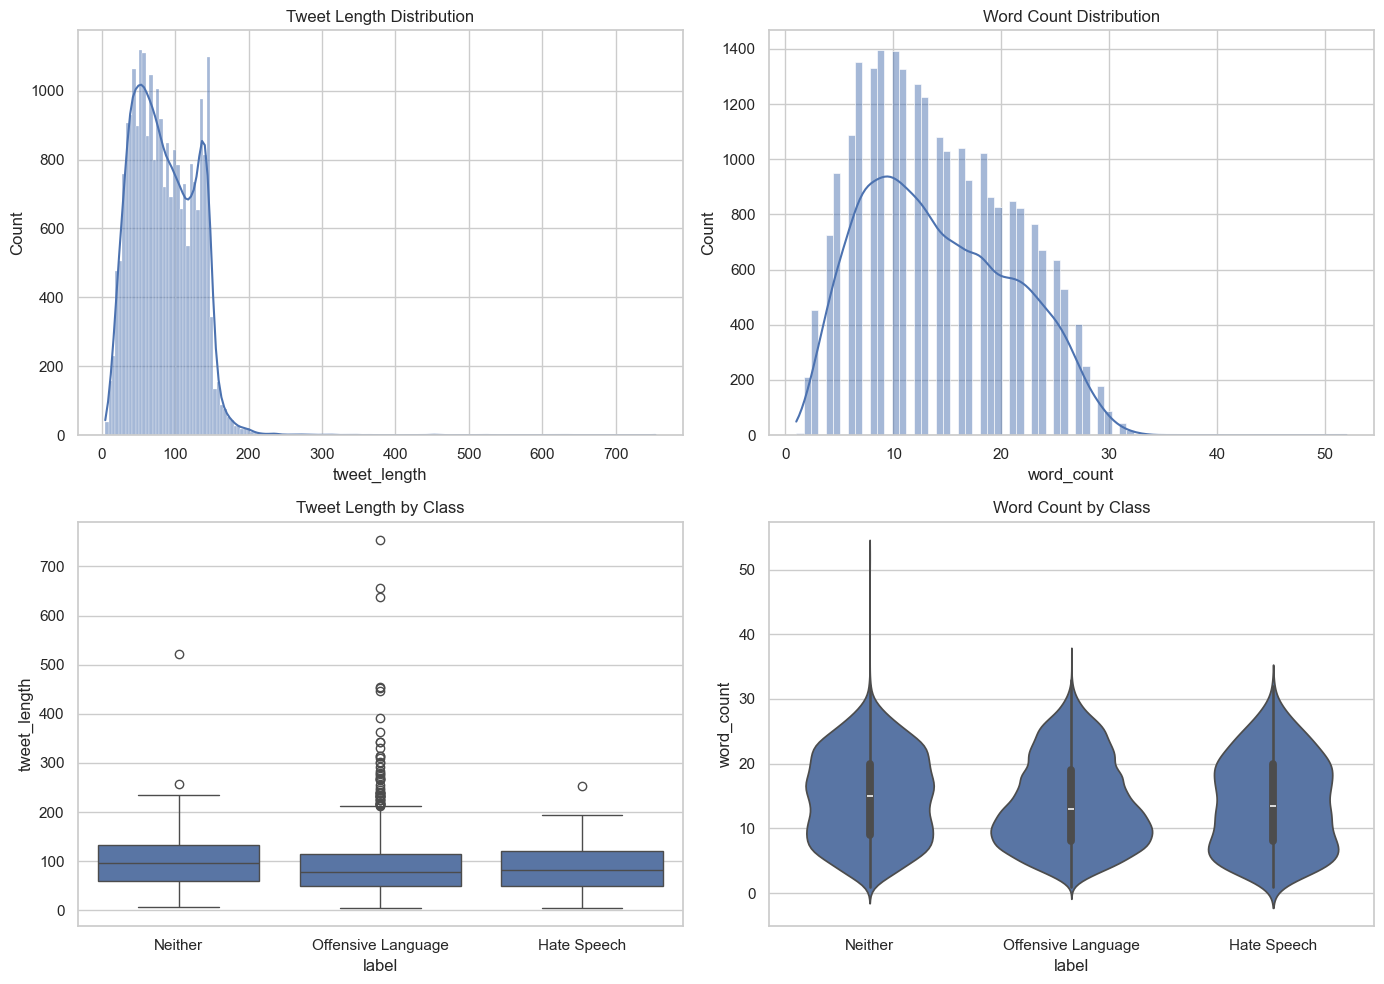

In [4]:

fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.histplot(df["tweet_length"], kde=True, ax=axes[0,0])
axes[0,0].set_title("Tweet Length Distribution")

sns.histplot(df["word_count"], kde=True, ax=axes[0,1])
axes[0,1].set_title("Word Count Distribution")

sns.boxplot(data=df, x="label", y="tweet_length", ax=axes[1,0])
axes[1,0].set_title("Tweet Length by Class")

sns.violinplot(data=df, x="label", y="word_count", ax=axes[1,1])
axes[1,1].set_title("Word Count by Class")

plt.tight_layout()
plt.show()


In [5]:

groups = [
    df[df.label == c]["tweet_length"]
    for c in df["label"].unique()
]

f_stat, p_val = stats.f_oneway(*groups)

print("ANOVA F-statistic:", f_stat)
print("p-value:", p_val)


ANOVA F-statistic: 130.2735368107815
p-value: 5.22745739704153e-57


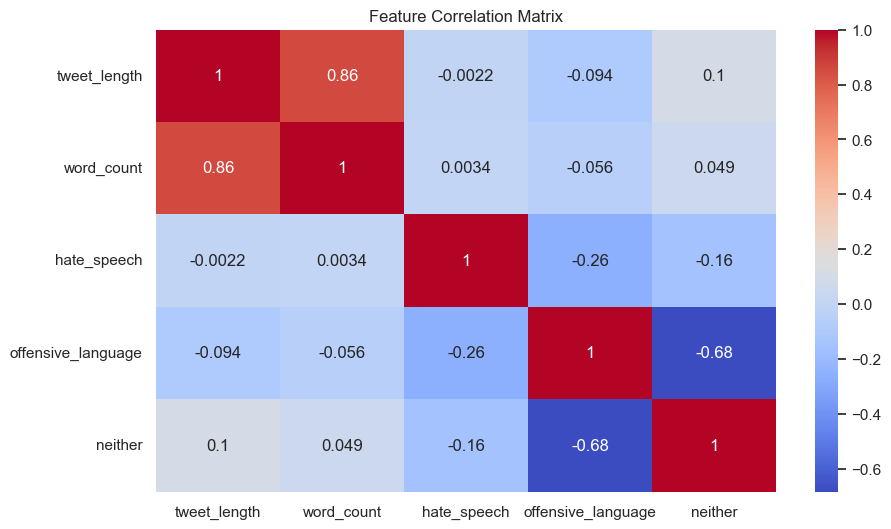

In [6]:

corr = df[["tweet_length","word_count","hate_speech",
           "offensive_language","neither"]].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


In [7]:

X = df["tweet"]
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [8]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

results = []

for name, model in models.items():
    
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=15000,
            ngram_range=(1,2),
            stop_words="english"
        )),
        ("model", model)
    ])
    
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std()
    })

pd.DataFrame(results).sort_values(
    "Mean Accuracy",
    ascending=False
)


,Model,Mean Accuracy,Std
2,Linear SVM,0.897710,0.004796
0,Logistic Regression,0.896853,0.003572
1,Naive Bayes,0.821245,0.003274


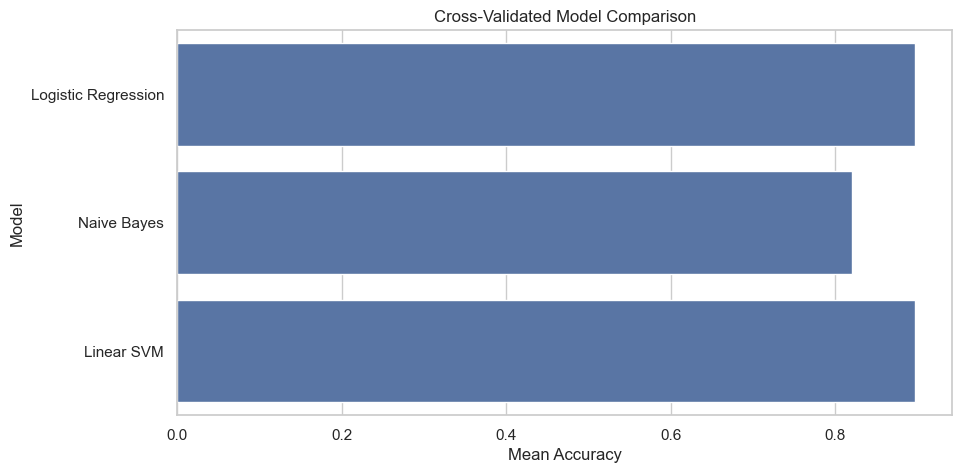

In [9]:

results_df = pd.DataFrame(results)

plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="Mean Accuracy",
    y="Model"
)

plt.title("Cross-Validated Model Comparison")
plt.show()


In [10]:

best_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1,2)
    )),
    ("model", LogisticRegression(max_iter=1000))
])

best_model.fit(X_train, y_train)

preds = best_model.predict(X_test)

print(classification_report(y_test, preds))


              precision    recall  f1-score   support

           0       0.66      0.13      0.22       286
           1       0.90      0.97      0.94      3838
           2       0.86      0.77      0.82       833

    accuracy                           0.89      4957
   macro avg       0.81      0.63      0.66      4957
weighted avg       0.88      0.89      0.87      4957



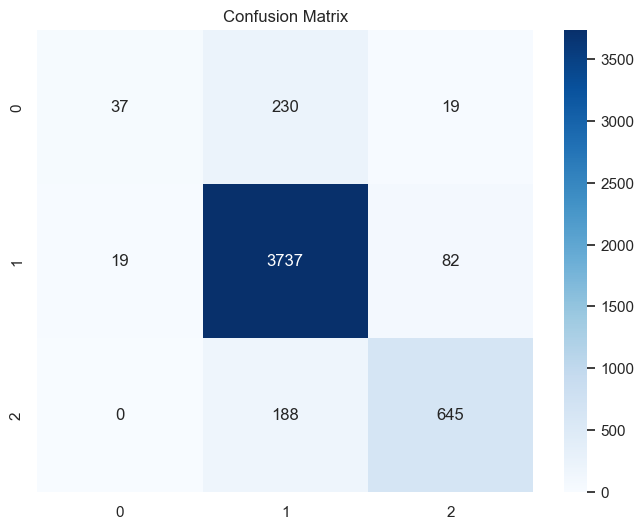

In [11]:

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [12]:

tfidf = best_model.named_steps["tfidf"]
model = best_model.named_steps["model"]

feature_names = np.array(tfidf.get_feature_names_out())

for idx, cls in enumerate(model.classes_):
    
    top = np.argsort(model.coef_[idx])[-20:]
    
    print("\nClass:", cls)
    print(feature_names[top])



Class: 0
['white trash' 'spic' 'hate' 'gay' 'fucking' 'racist' 'kill' 'queer'
 'dyke' 'ass' 'fags' 'fuck' 'fag' 'niggers' 'niggas' 'white' 'nigga'
 'nigger' 'faggots' 'faggot']

Class: 1
['fucked' 'these hoes' 'girl' 'this bitch' 'damn' 'that bitch' 'her' 'ain'
 'fucking' 'ass' 'fuck' 'cunt' 'niggah' 'pussies' 'shit' 'hoe' 'hoes'
 'pussy' 'bitches' 'bitch']

Class: 2
['redskins' 'chug' 'ghetto' 'monkey' 'sole' 'jihadi' '8230' 'brownie'
 'oreos' 'yankee' 'mock' 'oreo' 'brownies' 'colored' 'birds' 'trash'
 'yellow' 'charlie' 'yankees' 'bird']


In [13]:

tweet_stats = (
    df.groupby("label")
    .agg(
        tweets=("tweet","count"),
        avg_length=("tweet_length","mean"),
        avg_words=("word_count","mean")
    )
)

tweet_stats


,tweets,avg_length,avg_words
label,,,
Hate Speech,1430,84.586713,13.906993
Neither,4163,94.850108,14.919289
Offensive Language,19190,83.457113,13.958624


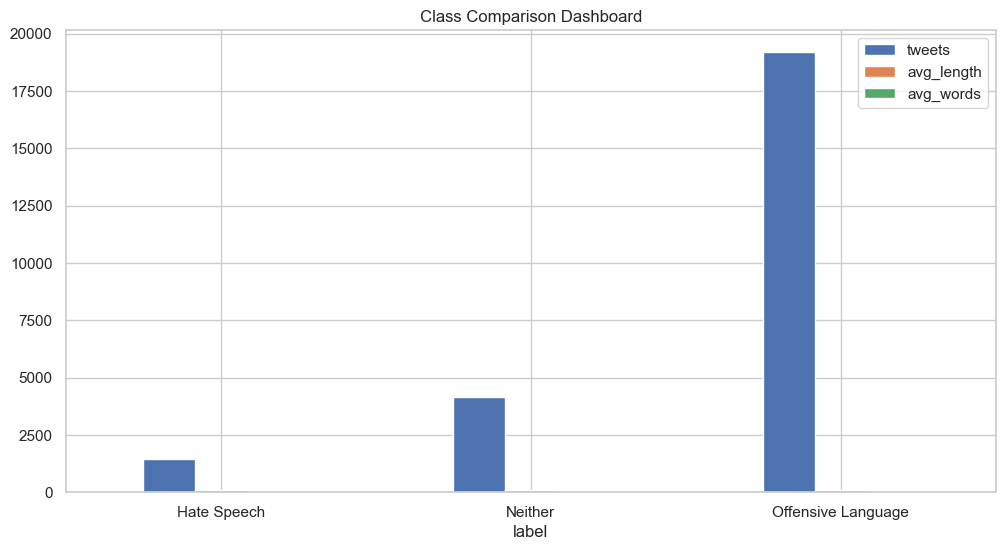

In [14]:

tweet_stats.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Class Comparison Dashboard")
plt.xticks(rotation=0)
plt.show()


In [15]:

errors = pd.DataFrame({
    "tweet": X_test,
    "actual": y_test,
    "predicted": preds
})

errors = errors[errors.actual != errors.predicted]

errors.head(20)


,tweet,actual,predicted
19777,RT @obeyyreggie: stfu hoe RT &#8220;@tedddydga...,0,1
22147,This store is SO redneck...,2,1
5586,@ballzahoy cowboy killers.&#128525;,2,1
2691,@Brizgotti These new nigga hipster hypebeasts ...,0,1
13415,Noap. Not taking them. RT @TiffNCompany: Maca ...,2,1
10307,I forgot how white trash Texarkana was... Well...,0,1
4585,@RunuldoRants faggot sack,0,1
12740,Man talk to em RT @StraightCash08: Of course n...,2,1
13803,People who never use any hair product are unke...,1,0
3875,@LaBugg09 &#128514;&#128514; my fault it sound...,2,1


In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("dark_background")

sns.set_theme(
    style="darkgrid",
    context="talk",
    palette="mako"
)

plt.rcParams.update({
    "figure.figsize": (12,6),
    "figure.facecolor": "#121212",
    "axes.facecolor": "#121212",
    "savefig.facecolor": "#121212",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white"
})

df = pd.read_csv("twitter.csv")

label_map = {
    0:"Hate Speech",
    1:"Offensive Language",
    2:"Neither"
}

df["label"] = df["class"].map(label_map)

df["tweet_length"] = df["tweet"].str.len()
df["word_count"] = df["tweet"].str.split().str.len()


C:\Users\soham\AppData\Local\Temp\ipykernel_36272\2622725001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df,x="label",palette="mako")


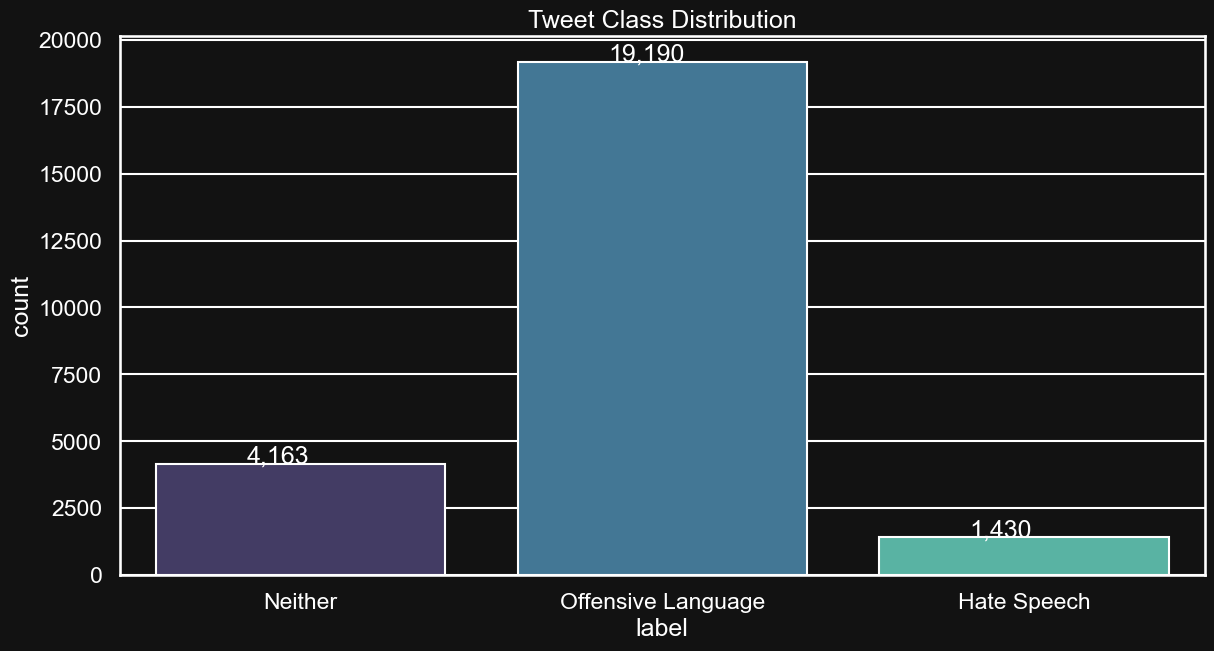

In [20]:

plt.figure(figsize=(14,7))
ax=sns.countplot(data=df,x="label",palette="mako")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x()+0.25,p.get_height()))
plt.title("Tweet Class Distribution")
plt.show()


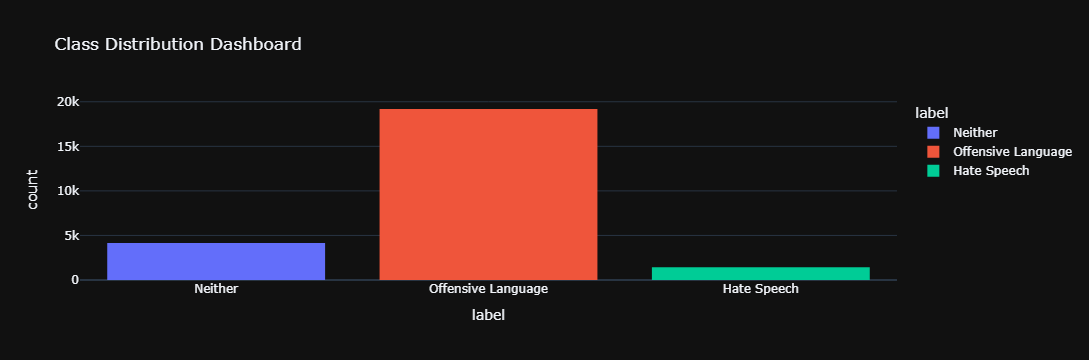

In [21]:

fig = px.histogram(
    df,
    x="label",
    color="label",
    template="plotly_dark",
    title="Class Distribution Dashboard"
)
fig.show()


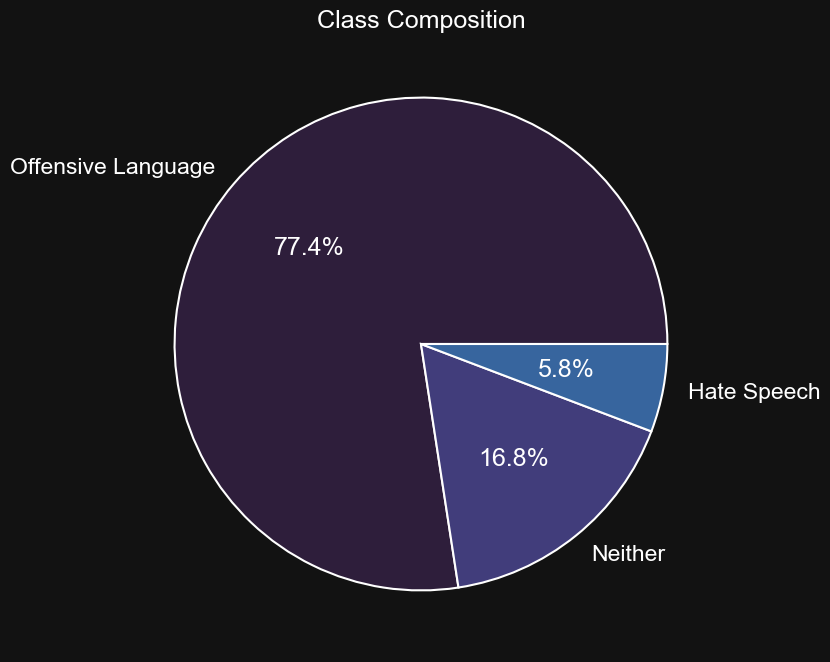

In [22]:

df.label.value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(8,8)
)
plt.title("Class Composition")
plt.ylabel("")
plt.show()


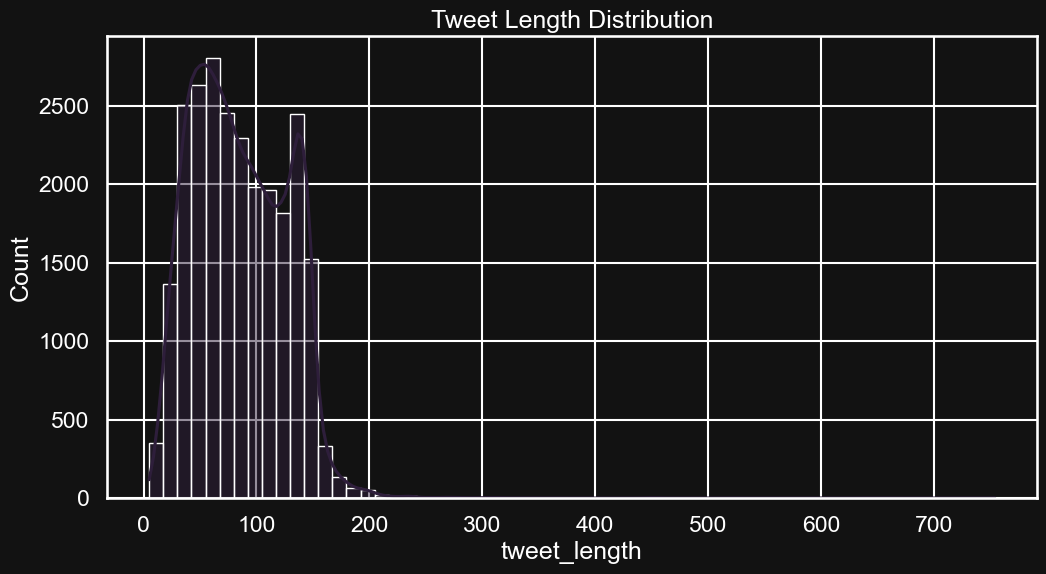

In [23]:

sns.histplot(df["tweet_length"],kde=True,bins=60)
plt.title("Tweet Length Distribution")
plt.show()


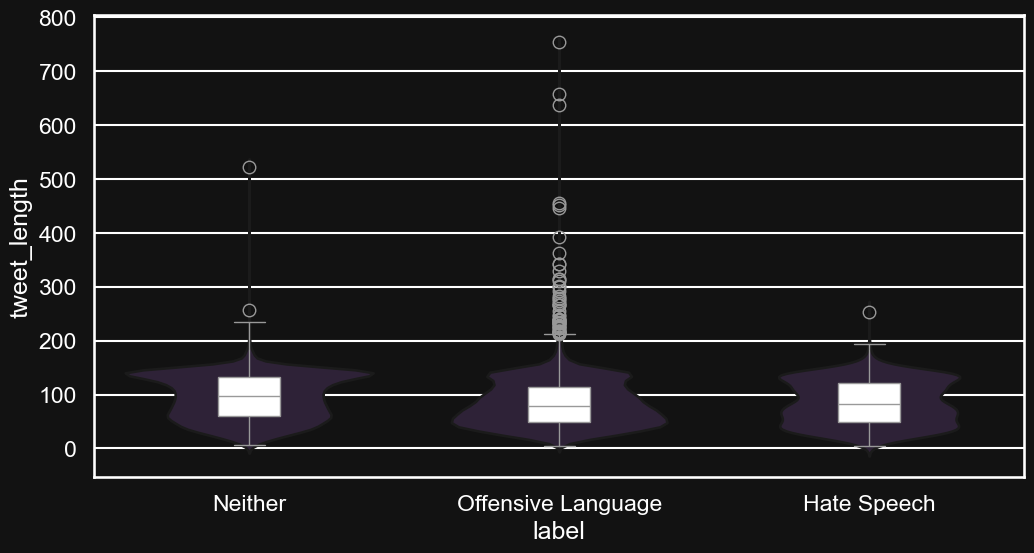

In [24]:

sns.violinplot(data=df,x="label",y="tweet_length",inner=None)
sns.boxplot(data=df,x="label",y="tweet_length",width=0.2,color="white")
plt.show()


<Axes: xlabel='tweet_length', ylabel='Proportion'>

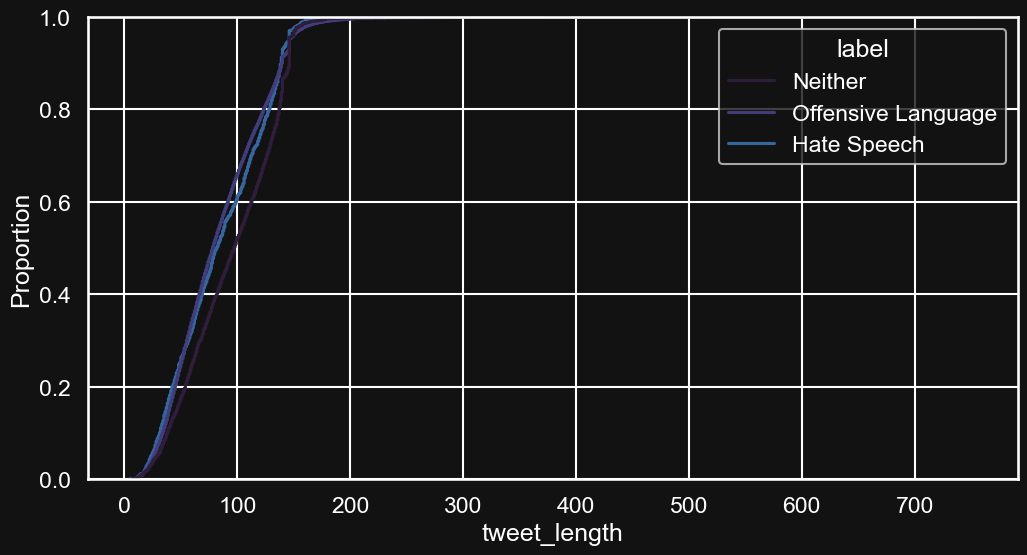

In [25]:
sns.ecdfplot(data=df,x="tweet_length",hue="label")


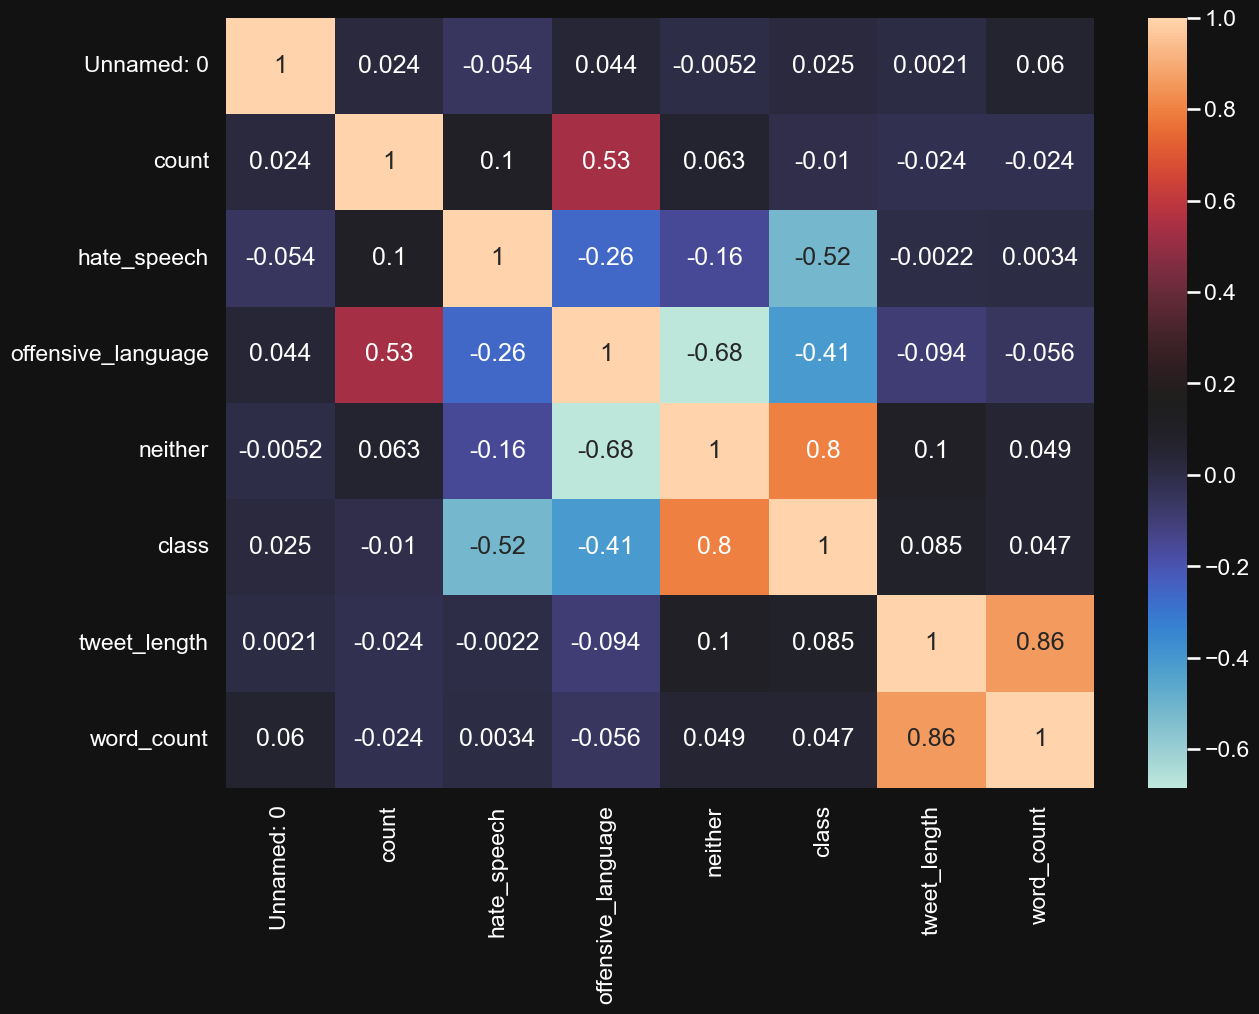

In [26]:

corr=df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr,annot=True,cmap="icefire")
plt.show()


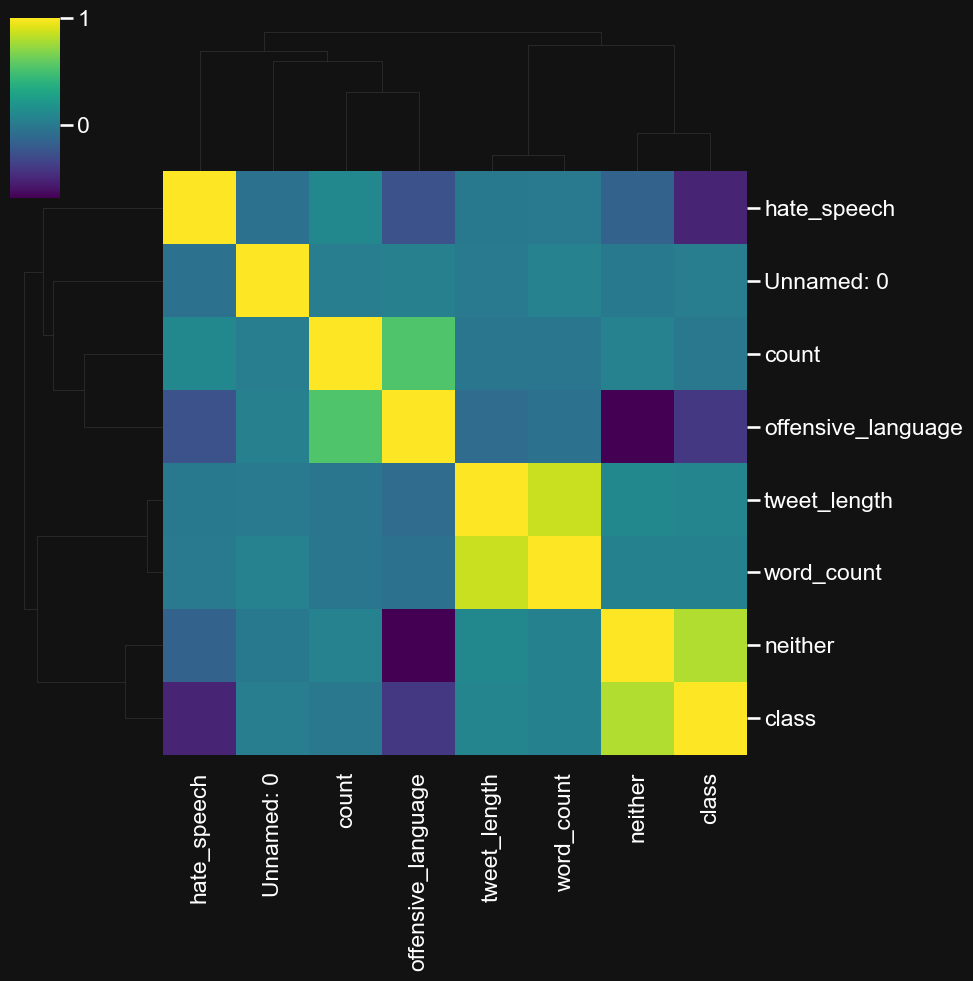

In [27]:

sns.clustermap(corr,cmap="viridis")
plt.show()


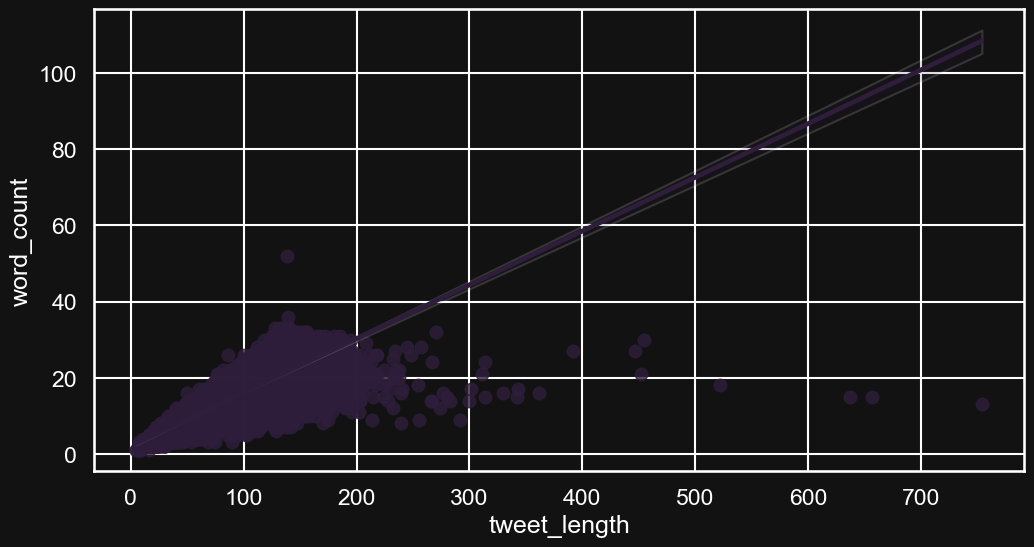

In [28]:

sns.regplot(data=df,x="tweet_length",y="word_count")
plt.show()


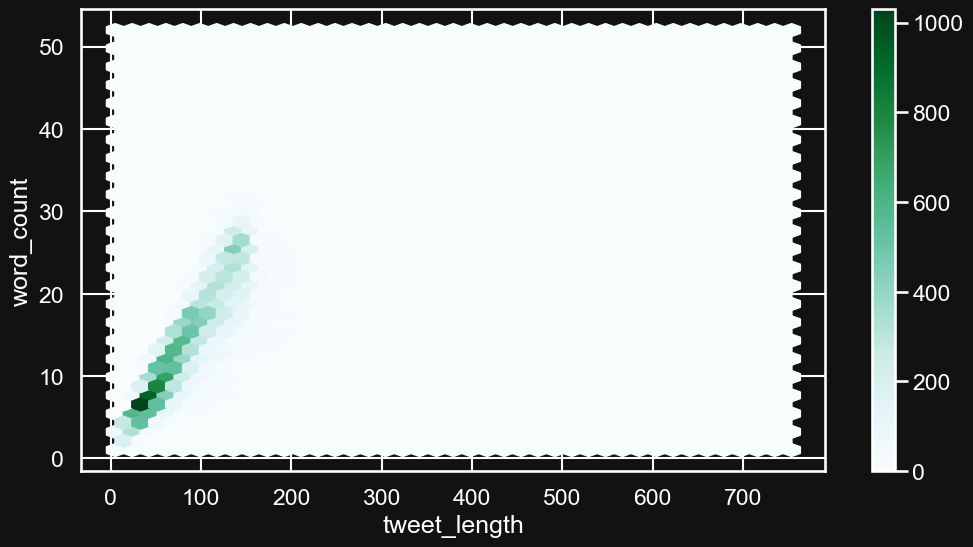

In [29]:

df.plot.hexbin(x="tweet_length",y="word_count",gridsize=40)
plt.show()


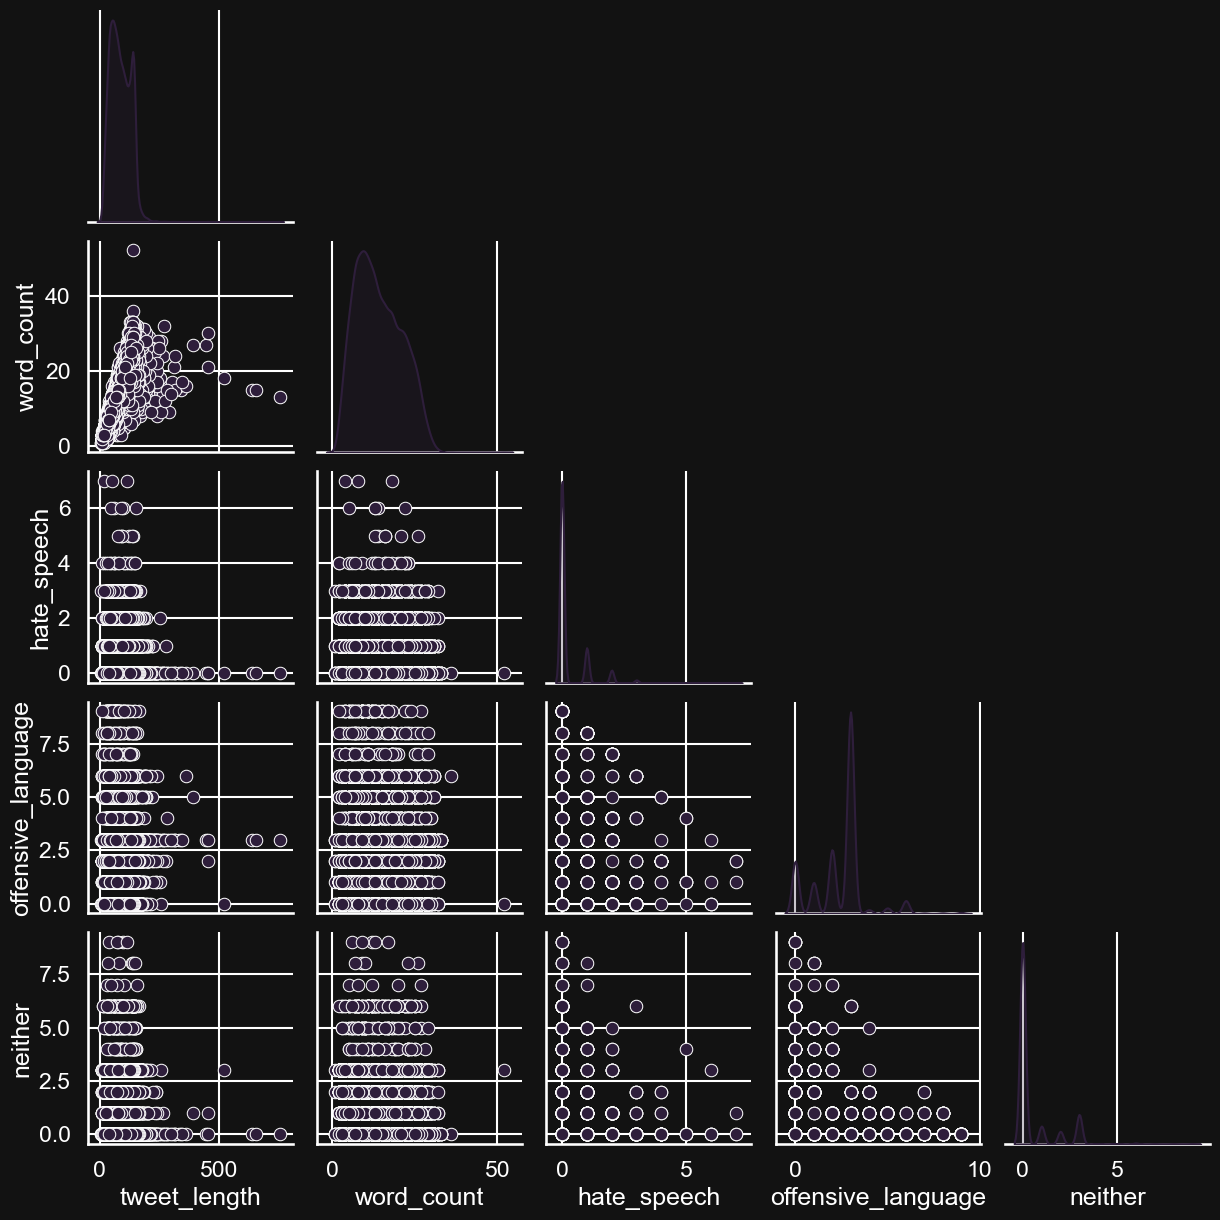

In [30]:

sns.pairplot(
df[[
'tweet_length',
'word_count',
'hate_speech',
'offensive_language',
'neither'
]],
corner=True,
diag_kind='kde'
)
